> **Snap Market model series.** We start from Carl's baseline momentum model and iterate to test it and improve it.
>
> **Notebook 05 — first improvement: add volatility.** Condition the momentum curve on the volatility regime (one curve per regime) and compare this `volatility_regime_momentum` model to the plain rolling momentum model.

# 05 — Momentum + volatility vs classic momentum (rolling)

Same comparison as notebooks 03 and 04, now between two rolling models:

- **momentum rolling** — the classic single curve P(up | momentum), shrinkage 0.40.
- **momentum + volatility** — the improved model: one momentum curve per volatility regime, shrinkage 0.40.

Both use the same window and shrinkage, so the only difference is the added volatility
dimension. The regime-aware attacker beat the classic model because that model ignores the
volatility regime; this notebook checks whether pricing that dimension closes the gap, and at
what cost on uninformed flow.

In [1]:
import os
import sys

# Move up one level to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# Add the new current directory to the Python path
sys.path.insert(0, os.getcwd())

In [2]:
from snapmarket.data import load_oracle_prices
from snapmarket.features import build_features
from snapmarket.parameters import SharedParameters
from snapmarket.models import build_model
from snapmarket.experiments import common_evaluation_start
from snapmarket.strategies import noise_pool
from snapmarket.engine import simulate

shared_parameters = SharedParameters()
features = build_features(load_oracle_prices(), shared_parameters)

models = {
    "momentum rolling": build_model("momentum_lookup_rolling", features, shared_parameters),
    "momentum + volatility": build_model("volatility_regime_momentum", features, shared_parameters),
}
model_labels = list(models)
palette = ["#9ca3af", "#2563eb"]
color_map = {label: palette[index] for index, label in enumerate(model_labels)}

evaluation_start = common_evaluation_start(models.values())
print(f"common evaluation start: second {evaluation_start:,} (~{evaluation_start / 86_400:.0f} days in)")
for label, model in models.items():
    spread = model.display_probability[evaluation_start:]
    print(f"  {label}: displayed p_up range [{spread.min():.3f}, {spread.max():.3f}]")

common evaluation start: second 7,776,605 (~90 days in)
  momentum rolling: displayed p_up range [0.434, 0.560]
  momentum + volatility: displayed p_up range [0.386, 0.601]


## Part 1 — Uninformed random flow

Non-overlapping windows of a balanced noise pool through both models with the same seed. This
measures the cost (if any) of the richer model on the dominant uninformed flow.

In [3]:
import numpy as np
import pandas as pd

window_length = 200_000          # seconds per window
number_of_windows = 8            # raise for a longer evaluation

rows = []
for window_index in range(number_of_windows):
    start = evaluation_start + window_index * window_length
    if start + window_length + shared_parameters.horizon_seconds >= features.number_of_seconds:
        break
    seed = 1_000 + window_index
    for label, model in models.items():
        result = simulate(model, features, {"noise": noise_pool()}, start, window_length, seed=seed)
        rows.append({
            "window": window_index,
            "model": label,
            "house_edge": result.house_edge,
            "house_pnl": result.house_pnl,
            "volume": result.total_volume,
        })

results = pd.DataFrame(rows)
print(f"{results['window'].nunique()} windows of {window_length:,} seconds each")
results.pivot(index="window", columns="model", values="house_edge")[model_labels]

8 windows of 200,000 seconds each


model,momentum rolling,momentum + volatility
window,,
0,0.128415,0.128844
1,0.131274,0.132288
2,0.125443,0.125964
3,0.127830,0.127983
4,0.130662,0.131050
5,0.128413,0.128831
6,0.126756,0.127519
7,0.127484,0.128206


In [4]:
summary = (results
           .groupby("model")
           .agg(mean_house_edge=("house_edge", "mean"),
                std_house_edge=("house_edge", "std"),
                total_house_pnl=("house_pnl", "sum"),
                total_volume=("volume", "sum"))
           .reindex(model_labels))
summary["aggregate_house_edge"] = summary["total_house_pnl"] / summary["total_volume"]

print(summary.to_string(formatters={
    "mean_house_edge": "{:+.3%}".format,
    "std_house_edge": "{:.3%}".format,
    "total_house_pnl": "${:,.0f}".format,
    "total_volume": "${:,.0f}".format,
    "aggregate_house_edge": "{:+.3%}".format,
}))

                      mean_house_edge std_house_edge total_house_pnl total_volume aggregate_house_edge
model                                                                                                 
momentum rolling             +12.828%         0.192%     $10,254,556  $79,937,696             +12.828%
momentum + volatility        +12.884%         0.200%     $10,298,561  $79,937,696             +12.883%


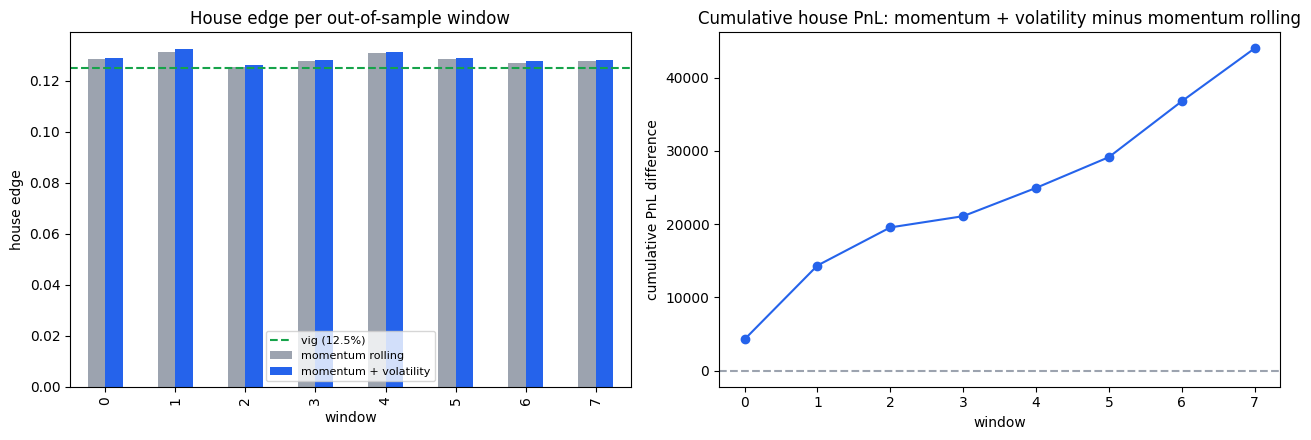

In [5]:
import matplotlib.pyplot as plt

edge_by_window = results.pivot(index="window", columns="model", values="house_edge")[model_labels]
house_pnl_by_window = results.pivot(index="window", columns="model", values="house_pnl")[model_labels]
pnl_difference = (house_pnl_by_window[model_labels[1]] - house_pnl_by_window[model_labels[0]]).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

edge_by_window.plot(kind="bar", ax=axes[0], color=color_map)
axes[0].axhline(shared_parameters.house_margin, ls="--", color="#16a34a",
                label=f"vig ({shared_parameters.house_margin:.1%})")
axes[0].set_title("House edge per out-of-sample window")
axes[0].set_xlabel("window"); axes[0].set_ylabel("house edge")
axes[0].legend(fontsize=8)

pnl_difference.plot(ax=axes[1], marker="o", color="#2563eb")
axes[1].axhline(0, ls="--", color="#9ca3af")
axes[1].set_title(f"Cumulative house PnL: {model_labels[1]} minus {model_labels[0]}")
axes[1].set_xlabel("window"); axes[1].set_ylabel("cumulative PnL difference")

plt.tight_layout(); plt.show()

## Part 2 — Informed attackers

The same three informed attackers, run inside a noise pool against each model. The key test is
the **regime-aware** attacker: if the improved model now prices the volatility regime, that
attacker's edge should shrink.

In [6]:
from snapmarket.data import load_fast_feed
from snapmarket.signals import walk_forward_logistic_probability, regime_conditional_probability
from snapmarket.strategies import predictive_bettor, lead_lag_bettor, regime_aware_bettor

fast_feed = load_fast_feed(expected_length=features.number_of_seconds)

logistic_probability = walk_forward_logistic_probability(features, shared_parameters)
regime_probability = regime_conditional_probability(features, shared_parameters)

informed_attackers = {
    "predictive (logistic)": predictive_bettor(logistic_probability),
    "lead-lag (fast feed)": lead_lag_bettor(features, fast_feed.log_price),
    "regime-aware": regime_aware_bettor(regime_probability),
}
print("informed attackers:", list(informed_attackers))

informed attackers: ['predictive (logistic)', 'lead-lag (fast feed)', 'regime-aware']


In [7]:
informed_window_length = 150_000
informed_number_of_windows = 6

attacker_rows = []
for model_label, model in models.items():
    for attacker_label, bettor in informed_attackers.items():
        attacker_pnl = attacker_stake = total_volume = 0.0
        for window_index in range(informed_number_of_windows):
            start = evaluation_start + window_index * informed_window_length
            if start + informed_window_length + shared_parameters.horizon_seconds >= features.number_of_seconds:
                break
            result = simulate(model, features,
                              {"pool": noise_pool(), "attacker": bettor},
                              start, informed_window_length, seed=200 + window_index)
            outcome = result.per_bettor["attacker"]
            attacker_pnl += outcome.pnl
            attacker_stake += outcome.stake
            total_volume += result.total_volume
        attacker_rows.append({
            "attacker": attacker_label,
            "model": model_label,
            "attacker_edge": attacker_pnl / attacker_stake if attacker_stake else 0.0,
            "volume_share": attacker_stake / total_volume if total_volume else 0.0,
        })

attacker_results = pd.DataFrame(attacker_rows)
attacker_edge = attacker_results.pivot(index="attacker", columns="model", values="attacker_edge")[model_labels]
attacker_edge

model,momentum rolling,momentum + volatility
attacker,,
lead-lag (fast feed),-0.172596,-0.171791
predictive (logistic),-0.046773,-0.040355
regime-aware,0.046678,0.029650


In [8]:
print("Attacker edge (PnL / stake), positive = beats the house:\n")
print(attacker_edge.to_string(formatters={label: "{:+.2%}".format for label in model_labels}))

edge_change = 1e4 * (attacker_edge[model_labels[1]] - attacker_edge[model_labels[0]])
print(f"\nAttacker edge change from '{model_labels[0]}' to '{model_labels[1]}' (basis points):\n")
print(edge_change.to_string(float_format="{:+.0f}".format))

Attacker edge (PnL / stake), positive = beats the house:

model                 momentum rolling momentum + volatility
attacker                                                    
lead-lag (fast feed)           -17.26%               -17.18%
predictive (logistic)           -4.68%                -4.04%
regime-aware                    +4.67%                +2.97%

Attacker edge change from 'momentum rolling' to 'momentum + volatility' (basis points):

attacker
lead-lag (fast feed)      +8
predictive (logistic)    +64
regime-aware            -170


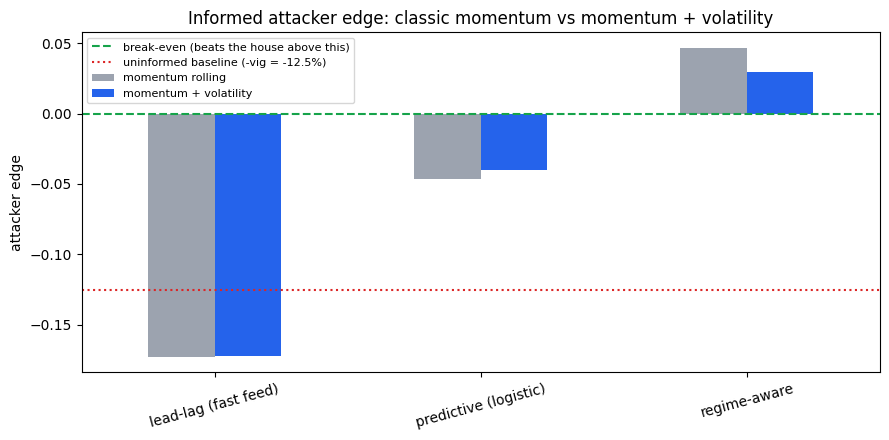

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
attacker_edge.plot(kind="bar", ax=ax, color=color_map)
ax.axhline(0, color="#16a34a", ls="--", label="break-even (beats the house above this)")
ax.axhline(-shared_parameters.house_margin, color="#dc2626", ls=":",
           label=f"uninformed baseline (-vig = {-shared_parameters.house_margin:.1%})")
ax.set_title("Informed attacker edge: classic momentum vs momentum + volatility")
ax.set_ylabel("attacker edge"); ax.set_xlabel("")
ax.legend(fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()